In [ ]:
# Iniciar o Colab com R
# https://colab.research.google.com/#create=true&language=r

In [ ]:
# -----------------------------------------------------------------------------
# Installing R packages
# keras: loading mnist dataset
# -----------------------------------------------------------------------------
packages = c("keras3")
for(pkg in packages) {
  if(!(pkg %in% rownames(installed.packages()))) {
    cat("Installing: ", pkg, "\n")
    install.packages(pkg)
  }
}

Installing:  keras3 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’, ‘dotty’




In [ ]:
# -----------------------------------------------------------------------------
# Loading packages
# -----------------------------------------------------------------------------
library("keras3")

In [ ]:
# Loading Mnist dataset
mnist = dataset_mnist()

In [ ]:
# -----------------------------------------------------------------------------
# training info
# -----------------------------------------------------------------------------
trainImages = mnist$train$x
trainLabels = mnist$train$y

# -----------------------------------------------------------------------------
# testing info
# -----------------------------------------------------------------------------
testImages = mnist$test$x
testLabels = mnist$test$y

In [ ]:
# -----------------------------------------------------------------------------
# Training set dimensions
# -----------------------------------------------------------------------------
print(dim(trainImages))
print(dim(trainLabels))

# -----------------------------------------------------------------------------
# Testing Set dimensions set dimensions
# -----------------------------------------------------------------------------
print(dim(testImages))
print(dim(testLabels))

[1] 60000    28    28
[1] 60000
[1] 10000    28    28
[1] 10000


[1] 5


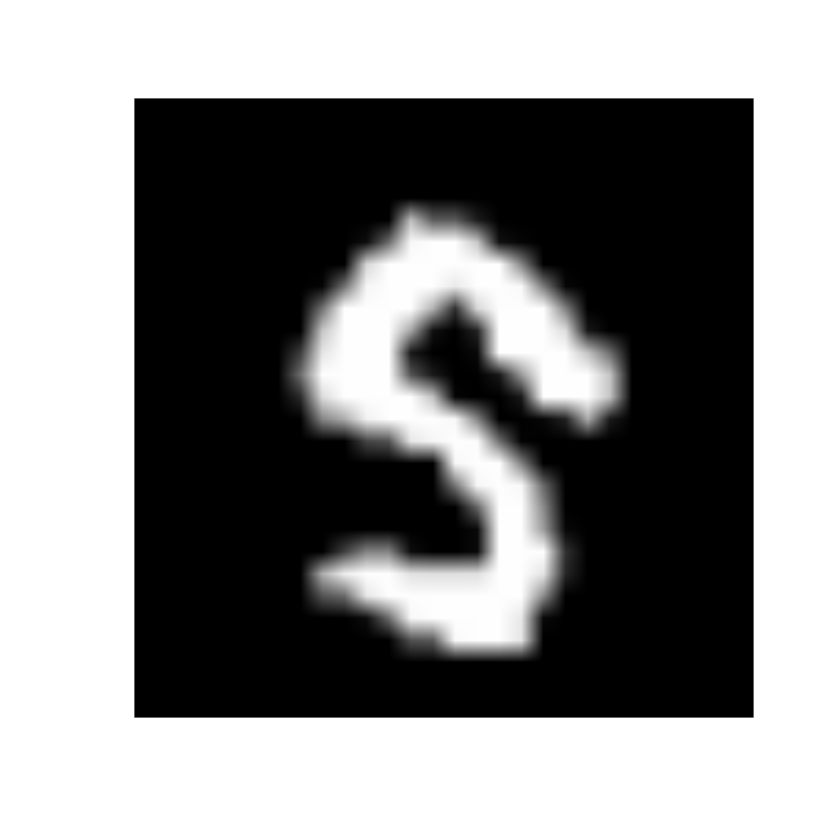

In [ ]:
# ------------------------------------------------------------------------------
# plotting first example as an image
# -----------------------------------------------------------------------------
id <- sample(60000,1)
plot(grDevices::as.raster(trainImages[id,,],max=255))
print(trainLabels[id])

In [ ]:
############ Teste Visual ###########
testa.digitos <- function(modelo, exemplos.teste, taxa.ruido = 0.1){

  taxa.ruido <- taxa.ruido # Probabilidade de um pixel ser trocado

	plotdim = 2*dim(exemplos.teste[1,,])
	plot(c(1,(plotdim[1]+5)*nrow(exemplos.teste)), c(1,(plotdim[2]+5)*3),
	          type="n", xlab="", ylab="")
	x = 1

	for (i in 1:nrow(exemplos.teste)) {
		padrao = exemplos.teste[i,,]/255 #normaliza values in [0,1]
		padrao = as.vector(ifelse(padrao >= 0.5, 1, 0))

		ruido = (runif(length(padrao), 0, 1) > taxa.ruido ) * 1
		entrada = padrao * ruido
		ret <- reconstrucao(modelo,entrada)

		# Padrao original
		img <- padrao;
		dim(img) <- dim(exemplos.teste[1,,])
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1, x + plotdim[1], plotdim[2], interpolate=F)

		# Entrada com ruido
		img <- entrada;
		dim(img) <- dim(exemplos.teste[1,,])
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1+(plotdim[2]+5), x + plotdim[1],
		            1+2*(plotdim[2]+5), interpolate=F)

		# Imagem recuperada
		img <- ret;
		dim(img) <- dim(exemplos.teste[1,,])
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1+2*(plotdim[2]+5), x + plotdim[1],
		            1+2*(plotdim[2]+5)+plotdim[2], interpolate=F)

		x = x + plotdim[1]+5
	}
}

In [ ]:
(runif(10, 0, 1) > 0.7)*1

[1] 0 0 0 0 1 0 0 0 1 0

In [ ]:
# Funcao de ativacao
funcao.ativacao <- function(v){
  y <- 1 / (1 + exp(-v))
  return(y)
}

# Funcao para amostragem
sample.bernoulli <- function(p){
  retorno <- 0

  if(runif(min=0,max=1,1) < p){
    retorno <- 1
  }

  return(retorno)
}

In [ ]:
# Funcao para construir a arquitetura
arquitetura <- function(num.visiveis, num.escondida, n, funcao.ativacao){

  arq <- list()
  arq$num.visiveis <- num.visiveis
  arq$num.escondida <- num.escondida
  arq$funcao.ativacao <- funcao.ativacao
  arq$n <- n

  # 2 neuronios na camada escondida
  #
  #     Ent1    Ent2    b
  # 1   w11     w12     w13
  # 2   w21     w22     w23

  # Pesos conectando camadas de entrada e escondida
  num.pesos.visivel.escondida <- num.visiveis * num.escondida
  arq$visivel.escondida <- matrix(runif(min=-1,max=1,num.pesos.visivel.escondida),
                                  nrow=num.escondida, ncol=num.visiveis)

  # Pesos conectando o bias e a camada escondida
  arq$bias.escondida <- runif(min=-1,max=1,num.escondida)

  # Pesos conectando o bias e a camada visivel
  arq$bias.visivel <- runif(min=-1,max=1,num.visiveis)

  return(arq)
}

In [ ]:
# Contrastive Divergence
contrastive.divergence <- function(exemplos,arq,K,epocas){

  # Para cada época
  for(i in 1:epocas){

    # Para cada exemplo
    for(j in 1:nrow(exemplos)){
      x <- exemplos[j,,]/255 #normaliza values in [0,1]
      x <- as.vector(ifelse(x >= 0.5, 1, 0))

      # Gibbs sampling -> corrigir aqui rapaziada
      for(k in 1:K){

        # p(h|x)
        v.h.x <- cbind(arq$visivel.escondida,arq$bias.escondida) %*% c(x,1)
        p.h.x <- as.numeric(arq$funcao.ativacao(v.h.x))
        bernoulli.p.h.x <- unlist(lapply(p.h.x,sample.bernoulli))

        # p(x|h) -> reconstrucao
        v.x.h <- t(c(bernoulli.p.h.x,1)) %*% rbind(arq$visivel.escondida,arq$bias.visivel)
        p.x.h <- as.numeric(arq$funcao.ativacao(v.x.h))
        bernoulli.p.x.h <- unlist(lapply(p.x.h,sample.bernoulli))
      }

      # p(h|~x) = h(~x)
      v.h.x.reconstruido <- cbind(arq$visivel.escondida,arq$bias.escondida) %*% c(bernoulli.p.x.h,1)
      p.h.x.reconstruido <- as.numeric(arq$funcao.ativacao(v.h.x.reconstruido))

      # Atualizacao de pesos

      # Pesos entre camada visivel e escondida
      deltaW <- p.h.x %*% t(x) - p.h.x.reconstruido %*% t(bernoulli.p.x.h)
      arq$visivel.escondida <- arq$visivel.escondida + arq$n * deltaW

      # Pesos entre bias e camada escondida
      arq$bias.escondida <- arq$bias.escondida + arq$n * (p.h.x - p.h.x.reconstruido)

      # Pesos entre bias e camada de entrada
      arq$bias.visivel <- arq$bias.visivel + arq$n * (x - bernoulli.p.x.h)
    }
  }
  return(arq)
}

In [ ]:
# Reconstrucao do padrao
reconstrucao <- function(modelo,padrao){

  # p(h|x)
  v.h.x <- cbind(modelo$visivel.escondida,modelo$bias.escondida) %*% c(padrao,1)
  p.h.x <- as.numeric(modelo$funcao.ativacao(v.h.x))
  bernoulli.p.h.x <- unlist(lapply(p.h.x,sample.bernoulli))

  # p(x|h) -> reconstrucao
  v.x.h <- t(c(bernoulli.p.h.x,1)) %*% rbind(modelo$visivel.escondida,modelo$bias.visivel)
  p.x.h <- as.numeric(modelo$funcao.ativacao(v.x.h))
  bernoulli.p.x.h <- unlist(lapply(p.x.h,sample.bernoulli))

  return(bernoulli.p.x.h)
}

In [ ]:
# Cria a arquitetura
arq <- arquitetura(length(trainImages[1,,]), length(trainImages[1,,])-100, 0.2, funcao.ativacao )
arq

0.68608904,0.4431488,0.1585929,1.544670e-01,-0.63545126,0.61408850,-0.001428386,0.32287826,-0.64228600,0.06216196,⋯,-0.01534320,-0.87918907,-0.454908000,0.27743277,-0.10626579,-0.291595054,0.47098950,0.89226275,0.025703577,0.085615616
-0.81652698,-0.7625466,0.9061196,-3.721949e-02,-0.56239716,-0.13749308,0.309600236,0.93904302,-0.23578119,0.37577284,⋯,0.95846184,-0.43488166,0.701279047,0.25388971,0.55299191,0.861310730,0.15944206,0.35542608,-0.707546905,0.168441314
-0.03192542,0.2836229,0.3381003,7.103700e-01,-0.24420046,0.57035648,-0.591753005,0.16736551,0.09787209,-0.91191944,⋯,-0.21120830,0.57885759,-0.029790349,0.28863291,0.04555514,-0.782653634,-0.91521397,-0.95159559,0.640121608,-0.465395326
0.25626197,-0.7632560,-0.9972648,-8.207466e-05,0.89968934,-0.41425003,0.643027211,-0.38899371,0.45152865,-0.13157200,⋯,-0.43601753,-0.15778670,-0.336121805,-0.66812952,-0.03693443,0.358428365,-0.37541987,-0.61566240,0.229474809,-0.490615891
-0.84584917,0.4534451,0.1959476,-2.890532e-01,-0.09928707,0.16616805,-0.236574450,-0.32786815,0.64894304,-0.96270464,⋯,0.91940249,-0.69630091,-0.392865957,0.07691751,0.53813492,-0.821591503,-0.09626341,-0.42287579,-0.008698183,0.063799643
-0.60201066,0.3809088,-0.6160202,5.669667e-01,0.16688505,0.85201038,-0.372239631,-0.59603227,-0.49625894,-0.76529981,⋯,0.74913673,0.58117068,-0.187084291,0.31910973,-0.40306513,-0.949467327,-0.61183815,0.39233427,0.545141314,-0.398628378
-0.09286621,-0.7050305,0.2352131,1.769075e-01,0.19089726,-0.64739749,0.399831473,-0.08551065,-0.99152680,-0.78888438,⋯,-0.53276764,0.98150885,-0.776128176,0.12657595,-0.46403908,0.947264066,-0.14557728,-0.46647521,-0.890916011,0.867144580
0.28713379,0.4539023,-0.8203823,8.549327e-01,0.57992563,0.63158140,-0.433406933,-0.36616316,-0.61826640,-0.63682463,⋯,-0.29485137,0.14752603,0.133122110,0.83155946,-0.84553484,-0.241092731,-0.04573303,0.60540837,0.500951034,0.945238634
-0.57881869,0.6703855,-0.3809381,-3.123634e-01,-0.66856413,0.79882026,-0.113399465,0.28905591,0.95123238,-0.69854242,⋯,0.91970340,-0.24577657,0.005593075,-0.22459822,0.69179806,0.006990659,0.70590827,-0.39924322,0.521761995,0.876926692
-0.90038713,-0.2813078,0.7269516,5.321043e-01,-0.29835925,-0.61396095,0.942394761,0.57487609,0.28206115,-0.60847961,⋯,-0.44360725,0.06838962,-0.866383907,0.23057736,-0.50064154,-0.028820944,-0.99393975,-0.95074959,-0.701974827,0.554930791
0.37998896,-0.2969173,-0.9104012,-1.118146e-01,-0.48160805,-0.51366582,-0.932528872,-0.20203822,0.69552892,0.66280275,⋯,0.22274386,0.05316550,0.120658062,0.18208291,0.33125675,-0.473210519,0.12676236,-0.33346462,0.705908176,0.268355714


In [ ]:
# Treinamento
modelo <- contrastive.divergence(trainImages[1:1000,,],arq,1,10)

In [ ]:
arq$visivel.escondida

0.68608904,0.4431488,0.1585929,1.544670e-01,-0.63545126,0.61408850,-0.001428386,0.32287826,-0.64228600,0.06216196,⋯,-0.01534320,-0.87918907,-0.454908000,0.27743277,-0.10626579,-0.291595054,0.47098950,0.89226275,0.025703577,0.085615616
-0.81652698,-0.7625466,0.9061196,-3.721949e-02,-0.56239716,-0.13749308,0.309600236,0.93904302,-0.23578119,0.37577284,⋯,0.95846184,-0.43488166,0.701279047,0.25388971,0.55299191,0.861310730,0.15944206,0.35542608,-0.707546905,0.168441314
-0.03192542,0.2836229,0.3381003,7.103700e-01,-0.24420046,0.57035648,-0.591753005,0.16736551,0.09787209,-0.91191944,⋯,-0.21120830,0.57885759,-0.029790349,0.28863291,0.04555514,-0.782653634,-0.91521397,-0.95159559,0.640121608,-0.465395326
0.25626197,-0.7632560,-0.9972648,-8.207466e-05,0.89968934,-0.41425003,0.643027211,-0.38899371,0.45152865,-0.13157200,⋯,-0.43601753,-0.15778670,-0.336121805,-0.66812952,-0.03693443,0.358428365,-0.37541987,-0.61566240,0.229474809,-0.490615891
-0.84584917,0.4534451,0.1959476,-2.890532e-01,-0.09928707,0.16616805,-0.236574450,-0.32786815,0.64894304,-0.96270464,⋯,0.91940249,-0.69630091,-0.392865957,0.07691751,0.53813492,-0.821591503,-0.09626341,-0.42287579,-0.008698183,0.063799643
-0.60201066,0.3809088,-0.6160202,5.669667e-01,0.16688505,0.85201038,-0.372239631,-0.59603227,-0.49625894,-0.76529981,⋯,0.74913673,0.58117068,-0.187084291,0.31910973,-0.40306513,-0.949467327,-0.61183815,0.39233427,0.545141314,-0.398628378
-0.09286621,-0.7050305,0.2352131,1.769075e-01,0.19089726,-0.64739749,0.399831473,-0.08551065,-0.99152680,-0.78888438,⋯,-0.53276764,0.98150885,-0.776128176,0.12657595,-0.46403908,0.947264066,-0.14557728,-0.46647521,-0.890916011,0.867144580
0.28713379,0.4539023,-0.8203823,8.549327e-01,0.57992563,0.63158140,-0.433406933,-0.36616316,-0.61826640,-0.63682463,⋯,-0.29485137,0.14752603,0.133122110,0.83155946,-0.84553484,-0.241092731,-0.04573303,0.60540837,0.500951034,0.945238634
-0.57881869,0.6703855,-0.3809381,-3.123634e-01,-0.66856413,0.79882026,-0.113399465,0.28905591,0.95123238,-0.69854242,⋯,0.91970340,-0.24577657,0.005593075,-0.22459822,0.69179806,0.006990659,0.70590827,-0.39924322,0.521761995,0.876926692
-0.90038713,-0.2813078,0.7269516,5.321043e-01,-0.29835925,-0.61396095,0.942394761,0.57487609,0.28206115,-0.60847961,⋯,-0.44360725,0.06838962,-0.866383907,0.23057736,-0.50064154,-0.028820944,-0.99393975,-0.95074959,-0.701974827,0.554930791
0.37998896,-0.2969173,-0.9104012,-1.118146e-01,-0.48160805,-0.51366582,-0.932528872,-0.20203822,0.69552892,0.66280275,⋯,0.22274386,0.05316550,0.120658062,0.18208291,0.33125675,-0.473210519,0.12676236,-0.33346462,0.705908176,0.268355714


In [ ]:
modelo$visivel.escondida

0.68596461,0.243138337,-0.04153264,-0.045530617,-0.6354838,0.61325392,-0.20143516,0.12288121,-0.84228558,-0.13783556,⋯,-0.223449719,-1.079185267,-0.45502008,0.24552233,-0.10629070,-0.291615109,0.07156361,0.88322099,0.02536227,-0.31387024
-0.81656284,-0.763334394,0.70927519,-0.237854093,-0.5628785,-0.16762159,0.08214586,0.93846654,-0.23636190,0.37519733,⋯,0.957849106,-0.435506009,0.52697284,0.25186219,0.55289616,0.662444332,-0.05807480,0.35538578,-0.70755654,-0.01898295
-0.83375677,-1.207973920,-0.64107815,-0.716844783,-0.8864611,-0.64833479,-1.22214468,-0.47254056,-0.33244108,-1.14232481,⋯,-1.243485040,-0.456240327,-1.85105745,-0.72973345,-0.55444496,-1.023747406,-1.75963880,-1.35145397,-0.96023935,-0.92860591
0.25607602,-0.887459770,-1.09441448,-0.103240606,0.6763997,-0.75791348,0.54845322,-0.67672650,0.35613191,-0.22723073,⋯,-0.560192016,-0.252499054,-0.52535398,-0.67673740,-0.23787174,0.358411060,-0.59860329,-0.98834297,0.02102988,-0.58552863
-0.84739733,0.441397534,0.10232870,-0.300844209,-0.1024169,0.15409239,-0.29054997,-0.34267027,0.63667431,-0.97446203,⋯,0.907601166,-0.708054082,-0.59307141,0.07687468,0.37956717,-0.822017177,-0.11725644,-0.58318174,-0.01256887,0.05152451
-0.60201088,0.180707948,-0.81601960,0.364827682,0.1668664,0.65203419,-0.57224993,-0.79603164,-0.69625884,-0.96529915,⋯,0.549137125,0.380838345,-0.18708459,0.31869687,-0.40308848,-0.949638807,-0.81184017,0.19235883,0.34868406,-0.59863859
-0.09286919,-0.904171359,0.03500812,-0.022303703,0.1902113,-0.64771465,0.20065678,-0.28465661,-1.19066893,-0.98803048,⋯,-0.731912465,0.782214296,-0.77644823,0.12550981,-0.46407568,0.947262867,-0.34477689,-0.46648187,-0.89110374,0.66800303
0.28638529,0.253594577,-1.02049653,0.654734436,0.5798862,0.63038371,-0.63490322,-0.56616020,-1.01821057,-0.83692241,⋯,-0.571980343,-0.052498584,0.13310900,0.83153984,-0.84563983,-0.241106554,-0.24693627,0.60523875,0.50074919,0.74516128
-0.57940007,0.270547719,-0.58106472,-0.674195134,-0.6685702,0.59881865,-0.31541414,-0.11075897,0.75083353,-0.90872318,⋯,0.539412683,-0.645124076,-0.19330679,-0.22466633,0.51529166,0.006633487,0.50537758,-0.39933366,0.52155068,0.47916584
-0.90040376,-0.481291670,0.52671131,0.332120656,-0.3046094,-0.61409382,0.74199873,0.37489680,0.08194868,-0.80853945,⋯,-0.643596676,-0.325139076,-0.86804167,0.23017455,-0.62198880,-0.028840714,-1.19391902,-0.95085558,-0.70299884,0.35487087
0.37998139,-0.959964756,-0.97461574,-0.373972101,-0.8806299,-0.71454440,-0.99606826,-0.46414225,0.23258181,0.38450056,⋯,-0.240524214,-0.009919892,0.12026930,-0.18067883,-0.26891759,-0.673220475,-0.72863230,-0.73364880,0.30383091,-0.25222278


In [ ]:
exemplos.teste <- testImages[1:10,,]
dim(exemplos.teste[1,,])

[1] 28 28

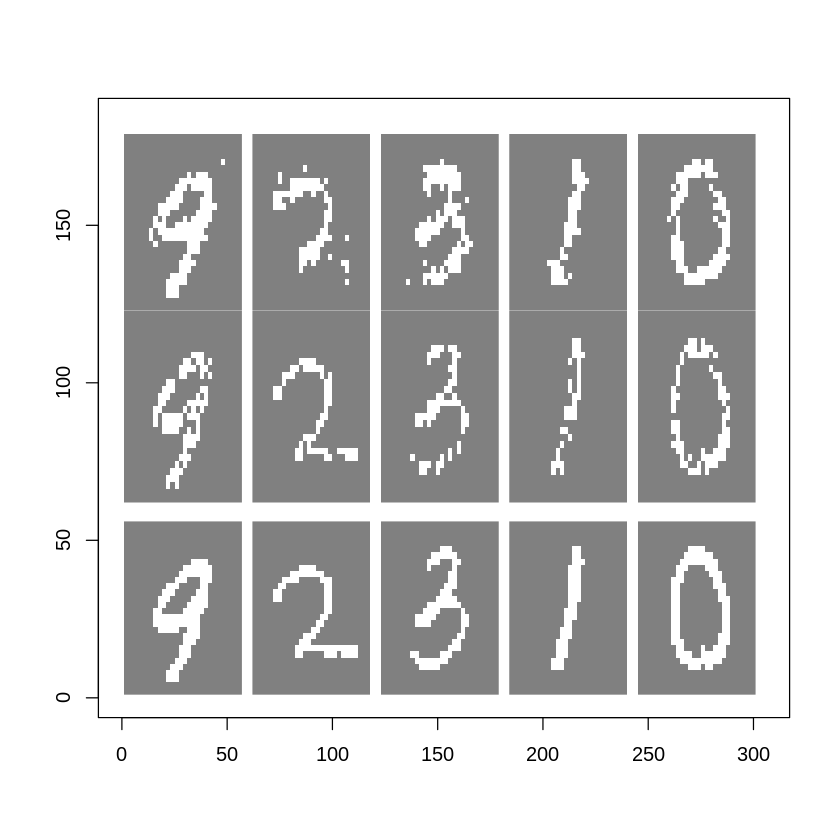

In [ ]:
testa.digitos(modelo, testImages[sample(nrow(testImages),5),,], taxa.ruido = 0.3)